# Import Dataset

[Link Dataset](https://www.kaggle.com/datasets/itssuru/health-insurance-premium-of-customers)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train_jRxnrHD.csv to train_jRxnrHD.csv


In [ ]:
import pandas as pd

df = pd.read_csv('train_jRxnrHD.csv')
df.head()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,sourcing_channel,residence_area_type,premium,target
0,110936,0.429,12058,355060,0.0,0.0,0.0,99.02,13,C,Urban,3300,1
1,41492,0.010,21546,315150,0.0,0.0,0.0,99.89,21,A,Urban,18000,1
2,31300,0.917,17531,84140,2.0,3.0,1.0,98.69,7,C,Rural,3300,0
3,19415,0.049,15341,250510,0.0,0.0,0.0,99.57,9,A,Urban,9600,1
4,99379,0.052,31400,198680,0.0,0.0,0.0,99.87,12,B,Urban,9600,1


# Data Preprocessing

In [ ]:
df.describe()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,target
count,79853.000000,79853.000000,79853.000000,7.985300e+04,79756.000000,79756.000000,79756.000000,76879.000000,79853.000000,79853.000000,79853.000000
mean,57167.166368,0.314288,18846.696906,2.088472e+05,0.248671,0.078188,0.060008,99.067291,10.863887,10924.507533,0.937397
std,32928.970160,0.334915,5208.719136,4.965826e+05,0.691468,0.436507,0.312023,0.739799,5.170687,9401.676542,0.242248
min,2.000000,0.000000,7670.000000,2.403000e+04,0.000000,0.000000,0.000000,91.900000,2.000000,1200.000000,0.000000
25%,28640.000000,0.034000,14974.000000,1.080100e+05,0.000000,0.000000,0.000000,98.810000,7.000000,5400.000000,1.000000
50%,57262.000000,0.167000,18625.000000,1.665600e+05,0.000000,0.000000,0.000000,99.210000,10.000000,7500.000000,1.000000
75%,85632.000000,0.538000,22636.000000,2.520900e+05,0.000000,0.000000,0.000000,99.540000,14.000000,13800.000000,1.000000
max,114076.000000,1.000000,37602.000000,9.026260e+07,13.000000,17.000000,11.000000,99.890000,60.000000,60000.000000,1.000000


In [ ]:
# One Hot Encoding
df = pd.get_dummies(df, columns=['sourcing_channel', 'residence_area_type'])
df.head()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,target,sourcing_channel_A,sourcing_channel_B,sourcing_channel_C,sourcing_channel_D,sourcing_channel_E,residence_area_type_Rural,residence_area_type_Urban
0,110936,0.429,12058,355060,0.0,0.0,0.0,99.02,13,3300,1,False,False,True,False,False,False,True
1,41492,0.010,21546,315150,0.0,0.0,0.0,99.89,21,18000,1,True,False,False,False,False,False,True
2,31300,0.917,17531,84140,2.0,3.0,1.0,98.69,7,3300,0,False,False,True,False,False,True,False
3,19415,0.049,15341,250510,0.0,0.0,0.0,99.57,9,9600,1,True,False,False,False,False,False,True
4,99379,0.052,31400,198680,0.0,0.0,0.0,99.87,12,9600,1,False,True,False,False,False,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79853 entries, 0 to 79852
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                79853 non-null  int64  
 1   perc_premium_paid_by_cash_credit  79853 non-null  float64
 2   age_in_days                       79853 non-null  int64  
 3   Income                            79853 non-null  int64  
 4   Count_3-6_months_late             79756 non-null  float64
 5   Count_6-12_months_late            79756 non-null  float64
 6   Count_more_than_12_months_late    79756 non-null  float64
 7   application_underwriting_score    76879 non-null  float64
 8   no_of_premiums_paid               79853 non-null  int64  
 9   premium                           79853 non-null  int64  
 10  target                            79853 non-null  int64  
 11  sourcing_channel_A                79853 non-null  bool   
 12  sour

Hasil one hot encoding masih dalam bentuk tipe data boolean, oleh karena itu perlu diubah menjadi integer

In [ ]:
# Mengubah kolom boolean menjadi integer
cols_to_convert = ['sourcing_channel_A', 'sourcing_channel_B', 'sourcing_channel_C', 'sourcing_channel_D',
                   'sourcing_channel_E','residence_area_type_Rural', 'residence_area_type_Urban']
for col in cols_to_convert:
    df[col] = df[col].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79853 entries, 0 to 79852
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                79853 non-null  int64  
 1   perc_premium_paid_by_cash_credit  79853 non-null  float64
 2   age_in_days                       79853 non-null  int64  
 3   Income                            79853 non-null  int64  
 4   Count_3-6_months_late             79756 non-null  float64
 5   Count_6-12_months_late            79756 non-null  float64
 6   Count_more_than_12_months_late    79756 non-null  float64
 7   application_underwriting_score    76879 non-null  float64
 8   no_of_premiums_paid               79853 non-null  int64  
 9   premium                           79853 non-null  int64  
 10  target                            79853 non-null  int64  
 11  sourcing_channel_A                79853 non-null  int64  
 12  sour

In [ ]:
df.head()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,target,sourcing_channel_A,sourcing_channel_B,sourcing_channel_C,sourcing_channel_D,sourcing_channel_E,residence_area_type_Rural,residence_area_type_Urban
0,110936,0.429,12058,355060,0.0,0.0,0.0,99.02,13,3300,1,0,0,1,0,0,0,1
1,41492,0.010,21546,315150,0.0,0.0,0.0,99.89,21,18000,1,1,0,0,0,0,0,1
2,31300,0.917,17531,84140,2.0,3.0,1.0,98.69,7,3300,0,0,0,1,0,0,1,0
3,19415,0.049,15341,250510,0.0,0.0,0.0,99.57,9,9600,1,1,0,0,0,0,0,1
4,99379,0.052,31400,198680,0.0,0.0,0.0,99.87,12,9600,1,0,1,0,0,0,0,1


**Penanganan Missing Values**

In [ ]:
import pandas as pd
missing_count = df.isnull().sum()
print(missing_count)

id                                     0
perc_premium_paid_by_cash_credit       0
age_in_days                            0
Income                                 0
Count_3-6_months_late                 97
Count_6-12_months_late                97
Count_more_than_12_months_late        97
application_underwriting_score      2974
no_of_premiums_paid                    0
premium                                0
target                                 0
sourcing_channel_A                     0
sourcing_channel_B                     0
sourcing_channel_C                     0
sourcing_channel_D                     0
sourcing_channel_E                     0
residence_area_type_Rural              0
residence_area_type_Urban              0
dtype: int64


Terdapat missing values pada 4 kolom. Oleh karena itu akan dilakukan penanganan dengan memeriksa distribusi datanya terlebih dahulu untuk mengetahaui penanganan apa yang perlu dilakukan

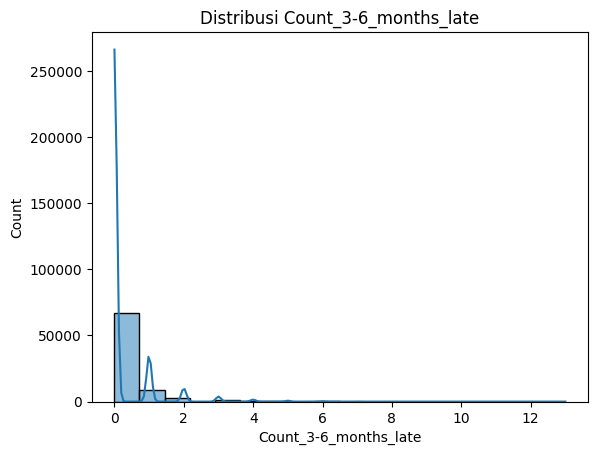

In [ ]:
# Memeriksa distrbusi data tiap kolom
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Count_3-6_months_late'].dropna(), kde=True)
plt.title('Distribusi Count_3-6_months_late')
plt.show()

Kolom terlihat cenderung left-skewed, oleh karena itu dilakukan penanganan dengan nilai median

In [ ]:
# Imputasi median
median_value = df['Count_3-6_months_late'].median()
df['Count_3-6_months_late'].fillna(median_value, inplace=True)

<ipython-input-11-09628fd52fef>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Count_3-6_months_late'].fillna(median_value, inplace=True)


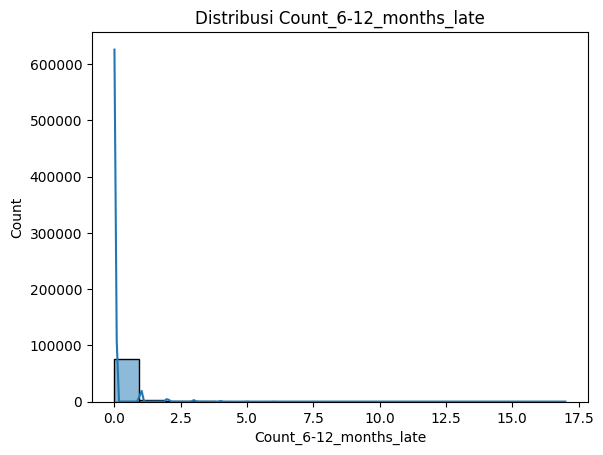

In [ ]:
sns.histplot(df['Count_6-12_months_late'].dropna(), kde=True)
plt.title('Distribusi Count_6-12_months_late')
plt.show()

Kolom terlihat cenderung left-skewed, oleh karena itu dilakukan penanganan dengan nilai median

In [ ]:
# Imputasi median
median_value = df['Count_6-12_months_late'].median()
df['Count_6-12_months_late'].fillna(median_value, inplace=True)

<ipython-input-13-ab9b5138d312>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Count_6-12_months_late'].fillna(median_value, inplace=True)


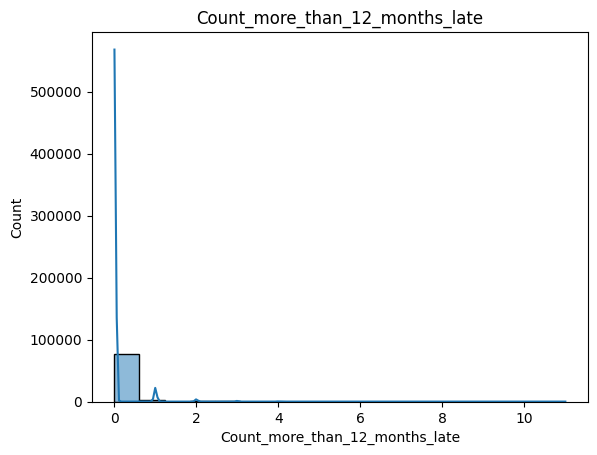

In [ ]:
sns.histplot(df['Count_more_than_12_months_late'].dropna(), kde=True)
plt.title('Count_more_than_12_months_late')
plt.show()

Kolom terlihat cenderung left-skewed, oleh karena itu dilakukan penanganan dengan nilai median

In [ ]:
# Imputasi median
median_value = df['Count_more_than_12_months_late'].median()
df['Count_more_than_12_months_late'].fillna(median_value, inplace=True)

<ipython-input-15-94d283d62973>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Count_more_than_12_months_late'].fillna(median_value, inplace=True)


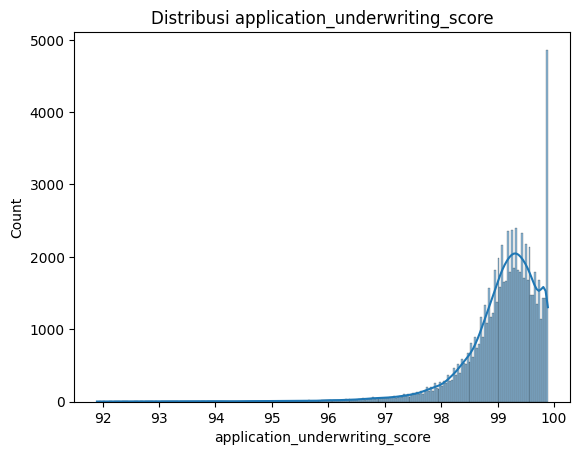

In [ ]:
sns.histplot(df['application_underwriting_score'].dropna(), kde=True)
plt.title('Distribusi application_underwriting_score')
plt.show()

Kolom terlihat cenderung right-skewed, oleh karena itu dilakukan penanganan dengan nilai median

In [ ]:
# Imputasi median
median_value = df['application_underwriting_score'].median()
df['application_underwriting_score'].fillna(median_value, inplace=True)

<ipython-input-17-af9656251783>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['application_underwriting_score'].fillna(median_value, inplace=True)


In [ ]:
missing_count = df.isnull().sum()
print(missing_count)

id                                  0
perc_premium_paid_by_cash_credit    0
age_in_days                         0
Income                              0
Count_3-6_months_late               0
Count_6-12_months_late              0
Count_more_than_12_months_late      0
application_underwriting_score      0
no_of_premiums_paid                 0
premium                             0
target                              0
sourcing_channel_A                  0
sourcing_channel_B                  0
sourcing_channel_C                  0
sourcing_channel_D                  0
sourcing_channel_E                  0
residence_area_type_Rural           0
residence_area_type_Urban           0
dtype: int64


**Mengubah umur dalam harian ke tahunan**

In [ ]:
df['age_in_days'] = (df['age_in_days'] / 365).astype(int)
df = df.rename(columns={'age_in_days': 'age_in_years'})
df.head()

,id,perc_premium_paid_by_cash_credit,age_in_years,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,target,sourcing_channel_A,sourcing_channel_B,sourcing_channel_C,sourcing_channel_D,sourcing_channel_E,residence_area_type_Rural,residence_area_type_Urban
0,110936,0.429,33,355060,0.0,0.0,0.0,99.02,13,3300,1,0,0,1,0,0,0,1
1,41492,0.010,59,315150,0.0,0.0,0.0,99.89,21,18000,1,1,0,0,0,0,0,1
2,31300,0.917,48,84140,2.0,3.0,1.0,98.69,7,3300,0,0,0,1,0,0,1,0
3,19415,0.049,42,250510,0.0,0.0,0.0,99.57,9,9600,1,1,0,0,0,0,0,1
4,99379,0.052,86,198680,0.0,0.0,0.0,99.87,12,9600,1,0,1,0,0,0,0,1


**Melakukan pemeriksaan kepentingan setiap kriteria**

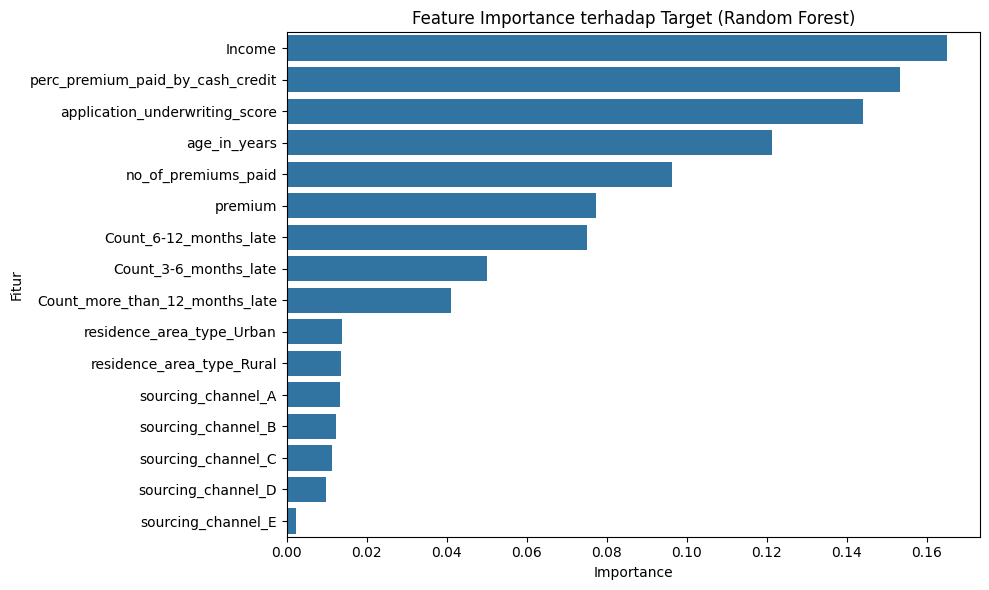

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Salin dataset dan siapkan X dan y
df_clean = df.copy()

# Pisahkan fitur dan target
X = df_clean.drop(columns=['id', 'target'])
y = df_clean['target']

# Latih Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Ambil feature importance
importances = model.feature_importances_
features = pd.Series(importances, index=X.columns)

# Urutkan dan tampilkan
features_sorted = features.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=features_sorted.values, y=features_sorted.index)
plt.title("Feature Importance terhadap Target (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

Terlihat bahwa kriteria "Income" merupakan fitur yang paling penting diikuti oleh kriteria-kriteria lainnya. Nilai "importance" ini kemudian digunakan untuk menghitung bobotnya dengan total estimasi dari setiap fiturnya adalah 0.860.

# Menentukan Alternatif dan Kriteria

Alternatif adalah ID. ID ini nantinya akan diurutkan berdasarkan ranking/peringkat. Peringkat tertinggi adalah pemegang polis terbaik yang dapat dijadikan prioritas/diberikan layanan yang lebih baik. Selain itu, pemeringkatan ini juga dapat digunakan untuk menentukan pemegang polis yang potensial sehingga pihak marketing dapat memaksimalkan strategi pemasaran.

Kriteria yang digunakan adalah:

1. Persentase Premi yang Sudah Dibayarkan
2. Usia
3. Penghasilan
4. Frekuensi pembayaran terlambat selama 3--6 bulan
5. Frekuensi pembayaran terlambat selama 6 bulan--12 bulan
6. Frekuensi pemabayran terlambat lebih dari 12 bulan
7. Skor underwriting
8. Jumlah premi yang Sudah Dibayarkan
9. Nominal premi
10. Sourcing channel (A, B, C, D, E)
11. Tipe residen (Rural, Urban)

In [ ]:
# Kolom kriteria
exclude_columns = ['id']
kriteria_columns = [col for col in df.columns if col not in exclude_columns]

# Kolom 'id' sebagai alternatif
df_ready = df.set_index('id')[kriteria_columns]

# Bentuk akhir data yang siap digunakan untuk TOPSIS
df_ready_shape = df_ready.shape
df_ready_preview = df_ready.head()

df_ready_shape, df_ready_preview

((79853, 17),
         perc_premium_paid_by_cash_credit  age_in_years  Income  \
 id                                                               
 110936                             0.429            33  355060   
 41492                              0.010            59  315150   
 31300                              0.917            48   84140   
 19415                              0.049            42  250510   
 99379                              0.052            86  198680   
 
         Count_3-6_months_late  Count_6-12_months_late  \
 id                                                      
 110936                    0.0                     0.0   
 41492                     0.0                     0.0   
 31300                     2.0                     3.0   
 19415                     0.0                     0.0   
 99379                     0.0                     0.0   
 
         Count_more_than_12_months_late  application_underwriting_score  \
 id                             

In [ ]:
import pandas as pd

# Pembobotan untuk setiap kriteria
def classify_linguistic(series, level=4):
    μ = series.mean()
    σ = series.std()

    if level == 4:
        bins = [float('-inf'), μ - 1.5 * σ, μ, μ + 1.5 * σ, float('inf')]
        labels = ['Rendah', 'Cukup', 'Tinggi', 'Sangat Tinggi']
    elif level == 3:
        bins = [float('-inf'), μ - σ, μ + σ, float('inf')]
        labels = ['Rendah', 'Cukup', 'Tinggi']
    else:
        raise ValueError("Level harus 3 atau 4")

    return pd.cut(series, bins=bins, labels=labels, include_lowest=True)

# Terapkan pada semua kolom numerik
linguistik_df = df.copy()
for col in linguistik_df.columns:
    linguistik_df[col] = classify_linguistic(linguistik_df[col], level=4)

# Lihat hasil
print(linguistik_df.head())

              id perc_premium_paid_by_cash_credit   age_in_years  Income  \
0  Sangat Tinggi                           Tinggi          Cukup  Tinggi   
1          Cukup                            Cukup         Tinggi  Tinggi   
2          Cukup                    Sangat Tinggi          Cukup   Cukup   
3          Cukup                            Cukup          Cukup  Tinggi   
4         Tinggi                            Cukup  Sangat Tinggi   Cukup   

  Count_3-6_months_late Count_6-12_months_late Count_more_than_12_months_late  \
0                 Cukup                  Cukup                          Cukup   
1                 Cukup                  Cukup                          Cukup   
2         Sangat Tinggi          Sangat Tinggi                  Sangat Tinggi   
3                 Cukup                  Cukup                          Cukup   
4                 Cukup                  Cukup                          Cukup   

  application_underwriting_score no_of_premiums_paid pre

# Triangular Fuzzy Numbers (TFN)

In [ ]:
# Mendefinisikan Triangular Fuzzy Numbers (TFN) untuk setiap label
# Ketentuan bilangan fuzzy dan varibel linguistik
fuzzy_scale = {
    'Sangat Rendah': (0.01, 0.01, 0.25),
    'Rendah': (0.01, 0.25, 0.5),
    'Cukup': (0.25, 0.5, 0.75),
    'Tinggi': (0.5, 0.75, 1.0),
    'Sangat Tinggi': (0.75,1.0,1.0),
}

# Defuzzifikasi (ambil rata-rata dari TFN)
def defuzzify(tfn):
    return (tfn[0] + tfn[1] + tfn[2]) / 3

# Ubah semua kategori linguistik menjadi nilai defuzzifikasi
defuzzified_df = linguistik_df.copy()
for col in defuzzified_df.columns:
    defuzzified_df[col] = defuzzified_df[col].map(lambda x: defuzzify(fuzzy_scale[x]))

print(defuzzified_df.head())

         id perc_premium_paid_by_cash_credit age_in_years Income  \
0  0.916667                         0.750000     0.500000   0.75   
1  0.500000                         0.500000     0.750000   0.75   
2  0.500000                         0.916667     0.500000   0.50   
3  0.500000                         0.500000     0.500000   0.75   
4  0.750000                         0.500000     0.916667   0.50   

  Count_3-6_months_late Count_6-12_months_late Count_more_than_12_months_late  \
0              0.500000               0.500000                       0.500000   
1              0.500000               0.500000                       0.500000   
2              0.916667               0.916667                       0.916667   
3              0.500000               0.500000                       0.500000   
4              0.500000               0.500000                       0.500000   

  application_underwriting_score no_of_premiums_paid premium    target  \
0                           0.

In [ ]:
print(defuzzified_df.dtypes)

id                                  category
perc_premium_paid_by_cash_credit    category
age_in_years                        category
Income                              category
Count_3-6_months_late               category
Count_6-12_months_late              category
Count_more_than_12_months_late      category
application_underwriting_score      category
no_of_premiums_paid                 category
premium                             category
target                              category
sourcing_channel_A                  category
sourcing_channel_B                  category
sourcing_channel_C                  category
sourcing_channel_D                  category
sourcing_channel_E                  category
residence_area_type_Rural           category
residence_area_type_Urban           category
dtype: object


In [ ]:
# drop Kolom "id" dan "target" dari defuzzified_df

defuzzified_df = defuzzified_df.drop(columns=['id', 'target'])

In [ ]:
for col in defuzzified_df.select_dtypes(include='category').columns:
    defuzzified_df[col] = defuzzified_df[col].astype(float)

# Matriks Pairwise Comparison

In [ ]:
import numpy as np
# Matriks Pairwise Comparison (16x16) sesuai skala Saaty
pairwise_matrix = np.array([
    # income, perc_premium, underwriting, age, premiums_paid, premium, Count6-12, Count3-6, Count12+, Urban, Rural, A, B, C, D, E
    [1, 1, 1, 2, 2, 3, 3, 4, 5, 6, 8, 9, 9, 9, 9, 9],       # income
    [1, 1, 1, 1, 2, 2, 3, 3, 5, 6, 7, 9, 9, 9, 9, 9],       # perc_premium_paid_by_cash_credit
    [1, 1, 1, 1, 2, 2, 2, 3, 4, 5, 6, 8, 9, 9, 9, 9],       # application_underwriting_score
    [1/2, 1, 1, 1, 1, 2, 2, 3, 3, 4, 5, 7, 8, 9, 9, 9],    # age_in_years
    [1/2, 1/2, 1/2, 1, 1, 1, 2, 2, 3, 3, 4, 5, 8, 9, 9, 9], # no_of_premiums_paid
    [1/3, 1/2, 1/2, 1/2, 1, 1, 1, 2, 2, 3, 3, 4, 6, 8, 9, 9], # premium
    [1/3, 1/3, 1/2, 1/2, 1/2, 1, 1, 1, 2, 2, 3, 3, 5, 7, 8, 9], # Count_6-12_months_late
    [1/4, 1/3, 1/3, 1/3, 1/2, 1/2, 1, 1, 1, 2, 3, 3, 4, 6, 7, 8], # Count_3-6_months_late
    [1/5, 1/5, 1/4, 1/3, 1/3, 1/2, 1/2, 1, 1, 1, 2, 2, 3, 4, 5, 6], # Count_more_than_12_months_late
    [1/6, 1/6, 1/5, 1/4, 1/3, 1/3, 1/2, 1/2, 1, 1, 1, 2, 3, 4, 5, 6], # residence_area_type_Urban
    [1/8, 1/7, 1/6, 1/5, 1/4, 1/3, 1/3, 1/3, 1/2, 1, 1, 1, 2, 3, 4, 5], # residence_area_type_Rural
    [1/9, 1/9, 1/8, 1/7, 1/5, 1/4, 1/3, 1/3, 1/2, 1/2, 1, 1, 1, 2, 3, 4], # sourcing_channel_A
    [1/9, 1/9, 1/9, 1/8, 1/8, 1/6, 1/5, 1/4, 1/3, 1/3, 1/2, 1, 1, 1, 2, 3], # sourcing_channel_B
    [1/9, 1/9, 1/9, 1/9, 1/9, 1/8, 1/7, 1/6, 1/4, 1/4, 1/3, 1/2, 1, 1, 1, 2], # sourcing_channel_C
    [1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/8, 1/7, 1/5, 1/5, 1/4, 1/3, 1/2, 1, 1, 1], # sourcing_channel_D
    [1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/8, 1/6, 1/6, 1/5, 1/4, 1/3, 1/2, 1, 1]  # sourcing_channel_E
])


# Fuzzy AHP

**Langkah 1: Konversi Matriks Perbandingan ke Fuzzy Triangular**

In [ ]:
def crisp_to_fuzzy(crisp_matrix):
    n = crisp_matrix.shape[0]
    fuzzy_matrix = np.zeros((n, n, 3))  # Setiap elemen memiliki 3 nilai (l, m, u)

    for i in range(n):
        for j in range(n):
            crisp_val = crisp_matrix[i, j]

            if crisp_val >= 1:
                # Untuk nilai >= 1: (crisp-0.5, crisp, crisp+0.5)
                fuzzy_matrix[i, j] = [max(0.1, crisp_val - 0.5), crisp_val, crisp_val + 0.5]
            else:
                # Untuk nilai < 1 (pecahan): (1/(1/crisp + 0.5), crisp, 1/(1/crisp - 0.5))
                reciprocal = 1 / crisp_val
                l_val = 1 / (reciprocal + 0.5)
                u_val = 1 / (reciprocal - 0.5) if reciprocal > 0.5 else 10  # Batasi nilai atas
                fuzzy_matrix[i, j] = [l_val, crisp_val, u_val]

    return fuzzy_matrix

# Konversi matriks crisp ke fuzzy
fuzzy_matrix = crisp_to_fuzzy(pairwise_matrix)

**Langkah 2: Hitung Nilai Sintetis (Synthetic Extent)**

In [ ]:
def calculate_synthetic_extent(fuzzy_matrix):
    n = fuzzy_matrix.shape[0]
    row_sums = np.zeros((n, 3))
    total_sum = np.zeros(3)

    # Hitung jumlah baris (l, m, u)
    for i in range(n):
        row_sums[i] = np.sum(fuzzy_matrix[i], axis=0)

    # Hitung total seluruh elemen
    total_sum = np.sum(row_sums, axis=0)

    # Hitung synthetic extent (S_i)
    S = np.zeros((n, 3))
    for i in range(n):
        S[i] = [
            row_sums[i, 0] / total_sum[2],  # l_i / total_u
            row_sums[i, 1] / total_sum[1],  # m_i / total_m
            row_sums[i, 2] / total_sum[0]   # u_i / total_l
        ]
    return S

**Langkah 3: Hitung Derajat Kemungkinan (Degree of Possibility)**

In [ ]:
def degree_of_possibility(S_i, S_j):
    l_i, m_i, u_i = S_i
    l_j, m_j, u_j = S_j

    if m_i >= m_j:
        return 1.0
    elif u_i <= l_j:
        return 0.0
    else:
        return (u_i - l_j) / ((u_i - m_i) + (m_j - l_j))

**Langkah 4: Hitung Bobot Kriteria**

In [ ]:
def calculate_fuzzy_weights(S):
    n = len(S)
    d = np.zeros(n)

    # Hitung derajat kemungkinan minimum untuk setiap kriteria
    for i in range(n):
        possibilities = []
        for j in range(n):
            if i != j:
                possibilities.append(degree_of_possibility(S[i], S[j]))
        d[i] = min(possibilities)

    # Normalisasi bobot
    w = d / d.sum()
    return w

**Langkah 5: Eksekusi Fuzzy AHP**

In [ ]:
# Hitung nilai sintetis
S = calculate_synthetic_extent(fuzzy_matrix)

# Hitung bobot kriteria
fuzzy_weights = calculate_fuzzy_weights(S)

# Tampilkan hasil bobot
criteria_names = [
    'Income', 'perc_premium_paid', 'underwriting_score', 'age_in_days',
    'premiums_paid', 'premium', 'Count_6-12_late', 'Count_3-6_late',
    'Count_12+_late', 'Urban', 'Rural', 'sourcing_A', 'sourcing_B',
    'sourcing_C', 'sourcing_D', 'sourcing_E'
]

weight_df = pd.DataFrame({
    'Kriteria': criteria_names,
    'Bobot': fuzzy_weights
})
print("\nBobot Kriteria dari Fuzzy AHP:")
print(weight_df.sort_values('Bobot', ascending=False))


Bobot Kriteria dari Fuzzy AHP:
              Kriteria     Bobot
0               Income  0.276199
1    perc_premium_paid  0.247082
2   underwriting_score  0.209323
3          age_in_days  0.156552
4        premiums_paid  0.093042
5              premium  0.017803
6      Count_6-12_late  0.000000
7       Count_3-6_late  0.000000
8       Count_12+_late  0.000000
9                Urban  0.000000
10               Rural  0.000000
11          sourcing_A  0.000000
12          sourcing_B  0.000000
13          sourcing_C  0.000000
14          sourcing_D  0.000000
15          sourcing_E  0.000000


**Langkah 6: Hitung Skor Prioritas Nasabah**

In [ ]:
# Print nama kolom
print(defuzzified_df.columns)

# Perbarui daftar nama_kriteria agar sesuai dengan nama kolom sebenarnya
criteria_names = [
    'Income',
    'perc_premium_paid_by_cash_credit',
    'application_underwriting_score',
    'age_in_years',
    'no_of_premiums_paid',
    'premium',
    'Count_6-12_months_late',
    'Count_3-6_months_late',
    'Count_more_than_12_months_late',
    'residence_area_type_Urban',
    'residence_area_type_Rural',
    'sourcing_channel_A',
    'sourcing_channel_B',
    'sourcing_channel_C',
    'sourcing_channel_D',
    'sourcing_channel_E'
]

# Hitung nilai sintetis
S = calculate_synthetic_extent(fuzzy_matrix)

# Hitung bobot kriteria
fuzzy_weights = calculate_fuzzy_weights(S)

# Tampilkan hasil bobot
weight_df = pd.DataFrame({
    'Kriteria': criteria_names,
    'Bobot': fuzzy_weights
})
print("\nBobot Kriteria dari Fuzzy AHP:")
print(weight_df.sort_values('Bobot', ascending=False))


# Pastikan kolom sesuai urutan kriteria
X = defuzzified_df[criteria_names]

# Hitung skor nasabah
nasabah_scores = X.dot(fuzzy_weights)

# Gabungkan dengan ID nasabah
results = pd.DataFrame({
    'id': df['id'],
    'Skor_Prioritas': nasabah_scores
})

# Urutkan berdasarkan skor tertinggi
results_sorted = results.sort_values('Skor_Prioritas', ascending=False)
print("\nTop 10 Nasabah Prioritas:")
print(results_sorted.head(10))

Index(['perc_premium_paid_by_cash_credit', 'age_in_years', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 'premium', 'sourcing_channel_A',
       'sourcing_channel_B', 'sourcing_channel_C', 'sourcing_channel_D',
       'sourcing_channel_E', 'residence_area_type_Rural',
       'residence_area_type_Urban'],
      dtype='object')

Bobot Kriteria dari Fuzzy AHP:
                            Kriteria     Bobot
0                             Income  0.276199
1   perc_premium_paid_by_cash_credit  0.247082
2     application_underwriting_score  0.209323
3                       age_in_years  0.156552
4                no_of_premiums_paid  0.093042
5                            premium  0.017803
6             Count_6-12_months_late  0.000000
7              Count_3-6_months_late  0.000000
8     Count_more_than_12_months_late  0.000000
9          residence_area_type_Urban  0.000

Berdasarkan hasil output di atas, maka dapat ditentukan 10 nasabah yang berpotensi untuk menjadi nasabah prioritas berdasarkan skor preferensi tertinggi. Dapat dilihat bahwa nasabah dengan id "56233" dan "104518" merupakan nasabah dengan skor preferensi tertinggi diikuti dengan nasabah-nasabah lainnya yang memiliki skor preferensi tidak terlalu jauh dari dua nasabah teratas.